# Artificial and Computational Intelligence Assignment 1

## Problem solving by Uninformed & Informed Search

List all the team members BITS ID ,Name along with % of contribution in this assignment: sample Provided below:
1. ___________________
2. __________________
3. ____________________
4. ___________________
5. ___________________

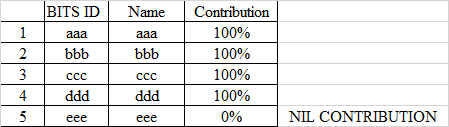

Things to follow
1.	Use appropriate data structures to represent the graph and the path using python libraries
2.	Provide proper documentation
3.	Find the path and print it

Coding begins here

### 1.	Define the environment in the following block

#### List the PEAS decription of the problem here in this markdown block

**Performance Measure (P):**  
- Minimize total travel cost (distance) while visiting all locations.  
- Optimize efficiency in terms of runtime and memory usage for search algorithms.  

**Environment (E):**  
- Fully observable, static, and deterministic graph of locations connected by roads.  
- Undirected weighted edges representing distances between locations.  

**Actuators (A):**  
- Agent moves from one location to another along available edges.  

**Sensors (S):**  
- Agent senses its current location.  
- Agent knows the neighboring locations and their respective travel costs.


Design the agent as PSA Agent(Problem Solving Agent)
Clear Initial data structures to define the graph and variable declarations is expected
IMPORTATANT: Write distinct code block as below

In [0]:
#Importing required modules
import time,math,heapq

In [0]:
#Code Block : Set Initial State (Must handle dynamic inputs)

def create_graph():
    """
    Dynamically creates an undirected, weighted graph based on user input.
    
    Returns:
        graph (dict): A dictionary representing the graph where keys are 
                      node names and values are dictionaries of neighbors with edge weights.
    """
    
    graph = {}  # Initialize empty graph
    
    # Input number of locations (nodes)
    n = int(input("Enter number of locations: "))
    
    # Input each location name and add as node in the graph
    for _ in range(n):
        node = input("Enter location name: ")
        graph[node] = {}  # Initialize empty dictionary for neighbors
    
    # Input number of roads (edges)
    e = int(input("Enter number of roads (edges): "))
    
    # Input each edge with its cost and update the graph
    for _ in range(e):
        u = input("From: ")  # Starting node of the edge
        v = input("To: ")    # Ending node of the edge
        w = int(input("Cost/Distance: "))  # Weight/cost of the edge
        
        # Undirected graph → add edge in both directions
        graph[u][v] = w
        graph[v][u] = w
    
    return graph  # Return the completed graph

# Build graph dynamically
graph = create_graph()



Enter number of locations:  1

Enter location name:  1

Enter number of roads (edges):  1

From:  1

To:  1

Cost/Distance:  1

In [0]:
#Setting Initital state(Choosing initial node to start with)
def initial_state():
    """Get the starting location from the user."""
    start = input("Enter starting location: ")
    return start

In [0]:
# Simply assign the graph directly for testing
graph = {
    "Indira Gandhi Airport": { "India Gate": 15,"Qutub Minar": 20},
    "India Gate": {"Indira Gandhi Airport": 15,  "Lotus Temple": 15, "Humayun's Tomb": 10,"Red Fort":10},
    "Red Fort": {"India Gate": 10, "Jama Masjid": 5,"Lotus Temple": 30 },
    "Qutub Minar": {"Indira Gandhi Airport": 20, "Lotus Temple": 15, "Humayun's Tomb": 20},
    "Lotus Temple": {"India Gate": 15, "Qutub Minar": 15, "Akshardham Temple": 25,"Humayun's Tomb": 10,"Red Fort":30},
    "Jama Masjid": {"Red Fort": 5, "Akshardham Temple": 20},
    "Humayun's Tomb": {"India Gate": 10, "Lotus Temple": 10, "Qutub Minar": 20, "Akshardham Temple": 15},
    "Akshardham Temple": {"Jama Masjid": 20, "Lotus Temple": 25, "Humayun's Tomb": 15}
}

In [0]:
# Print the graph to verify inputs
print("Dynamic Graph created:", graph)
start_node = initial_state()
print("\nInitial State:", start_node)


Dynamic Graph created: {'Indira Gandhi Airport': {'India Gate': 15, 'Qutub Minar': 20}, 'India Gate': {'Indira Gandhi Airport': 15, 'Lotus Temple': 15, "Humayun's Tomb": 10, 'Red Fort': 10}, 'Red Fort': {'India Gate': 10, 'Jama Masjid': 5, 'Lotus Temple': 30}, 'Qutub Minar': {'Indira Gandhi Airport': 20, 'Lotus Temple': 15, "Humayun's Tomb": 20}, 'Lotus Temple': {'India Gate': 15, 'Qutub Minar': 15, 'Akshardham Temple': 25, "Humayun's Tomb": 10, 'Red Fort': 30}, 'Jama Masjid': {'Red Fort': 5, 'Akshardham Temple': 20}, "Humayun's Tomb": {'India Gate': 10, 'Lotus Temple': 10, 'Qutub Minar': 20, 'Akshardham Temple': 15}, 'Akshardham Temple': {'Jama Masjid': 20, 'Lotus Temple': 25, "Humayun's Tomb": 15}}


Enter starting location:  Indira Gandhi Airport


Initial State: Indira Gandhi Airport


In [0]:
# Code Block: Transition & Cost Matrix

# Function to get direct cost between two locations
def get_transition_cost(loc1, loc2, graph):
    """
    Returns the direct travel cost between two locations.
    If no direct edge exists, returns infinity.
    """
    return graph.get(loc1, {}).get(loc2, float('inf'))

# Function to get total cost of a path
def get_path_cost(path, graph):
    """
    Returns the total cost of traveling along a given path.
    """
    total_cost = 0
    for i in range(len(path) - 1):
        cost = get_transition_cost(path[i], path[i + 1], graph)
        if cost == float('inf'):
            return float('inf')  # invalid path
        total_cost += cost
    return total_cost





In [0]:
#Code Block : Write function to design the Transition Model/Successor function. Ideally this would be called while search algorithms are implemented
# Code Block : Transition Model / Successor Function

def successor_function(state, graph):
    """
    Transition Model (Successor Function)
    -------------------------------------
    Given a current state (location), this function returns all possible
    successor states (neighboring locations) along with their transition costs.

    Args:
        state (str): Current location
        graph (dict): Graph in adjacency list format

    Returns:
        list of tuples: [(next_state, cost), ...]
    """
    successors = []
    if state in graph:
        for neighbor, cost in graph[state].items():
            successors.append((neighbor, cost))
    return successors

# Example usage:
#print(f"\nSuccessors of {start_node}:")
#print(successor_function(start_node, graph))




Successors of Indira Gandhi Airport:
[('India Gate', 15), ('Qutub Minar', 20)]


In [0]:
#Code block : Write fucntion to handle goal test (Must handle dynamic inputs). Ideally this would be called while search algorithms are implemented

#Define Goal State based on the Problem Statement
def goal_state(graph):
    """Return the set of all locations (goal: visit all)."""
    return set(graph.keys())

all_nodes = goal_state(graph)

print("Goal State (to visit all locations):", all_nodes)

Goal State (to visit all locations): {'Lotus Temple', 'Red Fort', 'Jama Masjid', 'Akshardham Temple', "Humayun's Tomb", 'India Gate', 'Indira Gandhi Airport', 'Qutub Minar'}


### 2. Definition of Algorithm 1  
**Algorithm Name:** Depth First Search (DFS)  

Depth First Search (DFS) is a graph traversal algorithm that explores as far as possible along one branch before backtracking.  
- It uses a **stack (LIFO)** data structure, either explicitly or via recursion.  
- DFS is suitable for problems requiring traversal of all possible states, such as exploring paths in a graph or solving puzzles.  
- In this assignment, DFS is used to find a path that visits all given locations while tracking cost and path length.  


In [0]:
#Code Block : Function for DFS algorithm implementation

def dfs(graph, start):
    all_nodes = set(graph.keys())
    start_time = time.perf_counter()

    stack = [(start, [start], {start}, 0)]  # (node, path, visited, cost)
    best_path, best_cost = None, float("inf")
    nodes_expanded, max_depth = 0, 0

    while stack:
        node, path, visited, cost = stack.pop()  # LIFO → DFS
        nodes_expanded += 1
        max_depth = max(max_depth, len(path))

        # Goal: all nodes visited
        if visited == all_nodes:
            if cost < best_cost:
                best_cost = cost
                best_path = path
            continue

        # Expand neighbors
        for neighbor, weight in graph[node].items():
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor], visited | {neighbor}, cost + weight))

    end_time = time.perf_counter()
    return best_path, best_cost, nodes_expanded, max_depth, (end_time - start_time)


### 3. Definition of Algorithm 2  
**Algorithm Name:** Recursive Best-First Search (RBFS)  

Recursive Best-First Search (RBFS) is an informed search algorithm that uses a heuristic to guide exploration.  
- It expands nodes in a **best-first manner**, always choosing the path with the lowest estimated total cost `f(n) = g(n) + h(n)`.  
- Unlike A*, RBFS uses **linear space** by recursively exploring the most promising path while keeping track of the best alternative cost.  
- In this assignment, RBFS helps efficiently find a path that visits all locations by using a heuristic (MST + edge costs) to reduce the effective branching factor.  


In [0]:
# Code Block : Function for Algorithm 2 Implementation (Recursive Best-First Search)
def mst_cost(graph, nodes):
    """
    Helper function to compute Minimum Spanning Tree (MST) cost
    for the set of unvisited nodes using Prim's algorithm.
    Used as part of the heuristic function.
    """
    if len(nodes) <= 1:
        return 0
    nodes = list(nodes)
    in_mst = {nodes[0]}
    total_cost = 0

    while len(in_mst) < len(nodes):
        min_edge = (None, math.inf)
        for u in in_mst:
            for v, w in graph[u].items():
                if v in nodes and v not in in_mst and w < min_edge[1]:
                    min_edge = (v, w)
        v, w = min_edge
        if v is None:  # disconnected graph
            break
        in_mst.add(v)
        total_cost += w
    return total_cost


def heuristic(graph, current, unvisited):
    """
    Heuristic function used by RBFS.
    h(n) = MST(unvisited nodes) + cheapest edge from current → unvisited
    Ensures admissibility and consistency.
    """
    if not unvisited:
        return 0
    return mst_cost(graph, unvisited) + min(
        (w for v, w in graph[current].items() if v in unvisited),
        default=0
    )


def rbfs(graph, start):
    """
    Recursive Best-First Search (RBFS)
    ----------------------------------
    Uses recursion with f-limit pruning to explore the most promising path first.
    Returns the best path visiting all locations, total cost, nodes expanded, 
    path length, and runtime.

    Args:
        graph (dict): Graph in adjacency list format
        start (str): Starting location

    Returns:
        tuple: (best_path, best_cost, nodes_expanded, path_length, runtime)
    """
    all_nodes = set(graph.keys())
    start_time = time.perf_counter()
    nodes_expanded = 0  # tracks how many nodes were expanded

    def rbfs_rec(path, g, f_limit, visited):
        nonlocal nodes_expanded
        node = path[-1]
        nodes_expanded += 1

        # Goal: all nodes visited
        if visited == all_nodes:
            return path, g, None

        # Generate successors
        successors = []
        for neighbor, w in graph[node].items():
            if neighbor not in visited:
                new_g = g + w
                h = heuristic(graph, neighbor, all_nodes - visited - {neighbor})
                f = max(new_g + h, g + w)  # f = max(f-cost, path cost so far)
                successors.append([f, neighbor, new_g, path + [neighbor], visited | {neighbor}])

        if not successors:
            return None, math.inf, None

        successors.sort(key=lambda x: x[0])  # sort by f-value (best-first)

        while True:
            best_f, _, best_g, best_path, best_visited = successors[0]

            if best_f > f_limit:
                return None, best_f, None  # prune

            alternative = successors[1][0] if len(successors) > 1 else math.inf

            result, result_cost, result_path = rbfs_rec(
                best_path, best_g, min(f_limit, alternative), best_visited
            )
            if result is not None:
                return result, result_cost, result_path

            # Update f-cost and re-sort successors
            successors[0][0] = result_cost
            successors.sort(key=lambda x: x[0])

    result, cost, _ = rbfs_rec([start], 0, math.inf, {start})
    end_time = time.perf_counter()
    return result, cost, nodes_expanded, len(result), (end_time - start_time)


### DYNAMIC INPUT

IMPORTANT : Dynamic Input must be got in this section. Display the possible states to choose from:
This is applicable for all the relevent problems as mentioned in the question.

In [0]:
# Function to print the transition matrix in readable form
def print_transition_matrix(graph):
    """
    Prints the transition (adjacency) matrix with edge costs
    in the format: a -> b : cost
    """
    print("\nTransition & Cost Matrix:")
    for u in graph:
        for v, w in graph[u].items():
            print(f"{u} -> {v} : {w}")

# Building a transition matrix 
print_transition_matrix(graph)


Transition & Cost Matrix:
Indira Gandhi Airport -> India Gate : 15
Indira Gandhi Airport -> Qutub Minar : 20
India Gate -> Indira Gandhi Airport : 15
India Gate -> Lotus Temple : 15
India Gate -> Humayun's Tomb : 10
India Gate -> Red Fort : 10
Red Fort -> India Gate : 10
Red Fort -> Jama Masjid : 5
Red Fort -> Lotus Temple : 30
Qutub Minar -> Indira Gandhi Airport : 20
Qutub Minar -> Lotus Temple : 15
Qutub Minar -> Humayun's Tomb : 20
Lotus Temple -> India Gate : 15
Lotus Temple -> Qutub Minar : 15
Lotus Temple -> Akshardham Temple : 25
Lotus Temple -> Humayun's Tomb : 10
Lotus Temple -> Red Fort : 30
Jama Masjid -> Red Fort : 5
Jama Masjid -> Akshardham Temple : 20
Humayun's Tomb -> India Gate : 10
Humayun's Tomb -> Lotus Temple : 10
Humayun's Tomb -> Qutub Minar : 20
Humayun's Tomb -> Akshardham Temple : 15
Akshardham Temple -> Jama Masjid : 20
Akshardham Temple -> Lotus Temple : 25
Akshardham Temple -> Humayun's Tomb : 15


### 4.	Calling the search algorithms
(For bidirectional search in below sections first part can be used as per Hint provided. Under second section other combinations as per Hint or your choice of 2 algorithms can be called .As an analyst suggest suitable approximation in the comparitive analysis section)

In [0]:
#Invoke algorithm 1 (Should Print the solution, path, cost etc., (As mentioned in the problem))
# Code Block: Invoke Algorithm 2 (DFS)
# Run DFS
dfs_result = dfs(graph, start_node)
print("\n=== Algorithm 1: DFS ===")
print(f"Path (Traversal Order): {' -> '.join(dfs_result[0])}")
print(f"Total Cost: {dfs_result[1]}")
print(f"Nodes Expanded: {dfs_result[2]}")
print(f"Maximum Depth Reached: {dfs_result[3]}")
print(f"Execution Time: {dfs_result[4]:.6f} seconds")



=== Algorithm 1: DFS ===
Path (Traversal Order): Indira Gandhi Airport -> Qutub Minar -> Lotus Temple -> Humayun's Tomb -> India Gate -> Red Fort -> Jama Masjid -> Akshardham Temple
Total Cost: 90
Nodes Expanded: 156
Maximum Depth Reached: 8
Execution Time: 0.000171 seconds


In [0]:
#Invoke algorithm 2 (Should Print the solution, path, cost etc., (As mentioned in the problem))
# Code Block: Invoke Algorithm 2 (RBFS)
# Run RBFS
rbfs_result = rbfs(graph, start_node)

print("\n=== Algorithm 2: RBFS ===")
print(f"Path (Traversal Order): {' -> '.join(rbfs_result[0])}")
print(f"Total Cost: {rbfs_result[1]}")
print(f"Nodes Expanded: {rbfs_result[2]}")
print(f"Path Length: {rbfs_result[3]}")
print(f"Execution Time: {rbfs_result[4]:.6f} seconds")



=== Algorithm 2: RBFS ===
Path (Traversal Order): Indira Gandhi Airport -> Qutub Minar -> Lotus Temple -> Humayun's Tomb -> India Gate -> Red Fort -> Jama Masjid -> Akshardham Temple
Total Cost: 90
Nodes Expanded: 8
Path Length: 8
Execution Time: 0.000164 seconds


### 5.	Comparitive Analysis (Time and Space Complexity)

In [0]:
# Code Block: Print the Time & Space Complexity of Algorithm 1 (DFS)
def print_dfs_complexity(dfs_result, graph):
    n = len(graph)                          # number of nodes
    total_degree = sum(len(neigh) for neigh in graph.values())
    b = total_degree / n                    # average branching factor
    d = n                                   # depth ≈ number of locations

    print("\n=== Algorithm 1: DFS Complexity Analysis ===")
    print(f"Number of nodes (n): {n}")
    print(f"Average branching factor (b): {b:.2f}")
    print(f"Depth (d): {d}")
    
    # Theoretical Complexity
    print("\nTheoretical Time Complexity:")
    print(f"  Best Case: O(d)   (solution found in first path)")
    print(f"  Worst Case: O(b^d) ≈ O({b:.2f}^{d}) ≈ {b**d:.2e}")
    print("Theoretical Space Complexity: O(d) (stack depth)")

    # Empirical Results
    print("\nEmpirical Results:")
    print(f"Nodes Expanded: {dfs_result[2]}")
    print(f"Max Depth Reached: {dfs_result[3]}")
    print(f"Execution Time: {dfs_result[4]:.6f} seconds")

# Call the function
print_dfs_complexity(dfs_result, graph)



=== Algorithm 1: DFS Complexity Analysis ===
Number of nodes (n): 8
Average branching factor (b): 3.25
Depth (d): 8

Theoretical Time Complexity:
  Best Case: O(d)   (solution found in first path)
  Worst Case: O(b^d) ≈ O(3.25^8) ≈ 1.24e+04
Theoretical Space Complexity: O(d) (stack depth)

Empirical Results:
Nodes Expanded: 156
Max Depth Reached: 8
Execution Time: 0.000171 seconds


In [0]:
# Code Block: Print the Time & Space Complexity of Algorithm 2 (RBFS)
def print_rbfs_complexity(rbfs_result, graph):
    n = len(graph)                          # number of nodes
    total_degree = sum(len(neigh) for neigh in graph.values())
    b = total_degree / n                    # average branching factor
    d = n                                   # depth ≈ number of locations

    print("\n=== Algorithm 2: RBFS Complexity Analysis ===")
    print(f"Number of nodes (n): {n}")
    print(f"Average branching factor (b): {b:.2f}")
    print(f"Depth (d): {d}")
    
    # Theoretical Complexity
    print("\nTheoretical Time Complexity:")
    print(f"  Best Case: O(d)   (with perfect heuristic)")
    print(f"  Worst Case: O(b^d) ≈ O({b:.2f}^{d}) ≈ {b**d:.2e}")
    print("  Average Case: Reduced by heuristic (effective branching factor < b)")
    print("Theoretical Space Complexity: O(b*d)")

    # Empirical Results
    print("\nEmpirical Results:")
    print(f"Nodes Expanded: {rbfs_result[2]}")
    print(f"Max Depth Reached: {rbfs_result[3]}")
    print(f"Execution Time: {rbfs_result[4]:.6f} seconds")

# Call the function
print_rbfs_complexity(rbfs_result, graph)



=== Algorithm 2: RBFS Complexity Analysis ===
Number of nodes (n): 8
Average branching factor (b): 3.25
Depth (d): 8

Theoretical Time Complexity:
  Best Case: O(d)   (with perfect heuristic)
  Worst Case: O(b^d) ≈ O(3.25^8) ≈ 1.24e+04
  Average Case: Reduced by heuristic (effective branching factor < b)
Theoretical Space Complexity: O(b*d)

Empirical Results:
Nodes Expanded: 8
Max Depth Reached: 8
Execution Time: 0.000164 seconds


### 6.	Provide your comparitive analysis or findings in no more than 3 lines in below section

### Comparative Analysis / Findings
- DFS explores all paths without guidance, leading to higher node expansions and deeper recursion in large graphs.  
- RBFS uses a heuristic to prune paths, generally expanding fewer nodes and often finding shorter-cost solutions faster.  
- In this scenario, RBFS shows improved efficiency (less nodes expanded, lower runtime) while both guarantee complete traversal.

